# ROI Lens: Marketing Spend Optimization

## Marketing Analytics Case Study

### Prepared By

Nihira Singh

Rohit Virayas

Saurabh Kumar

# Table of Contents

1. Introduction
2. Data Overview
3. Data Quality Assessment
   - Missing Value Analysis
   - Duplicate Record Analysis

4. Fraud & Anomaly Detection
   - High-Interaction User Analysis
   - Suspicious Traffic Identification

5. Customer Journey Analysis
   - Journey Length Distribution
   - Purchase Path Analysis

6. Channel Performance Analysis
   - Conversion Rate Analysis
   - Cost Per Acquisition (CPA) Analysis

7. Campaign Performance Analysis
   - Campaign-Level CPA Comparison
   - Best & Worst Performing Campaigns

8. User Behavior & Frequency Analysis
   - Customer Engagement Patterns
   - Frequency Cap Simulation

9. Attribution Analysis
   - Last-Click Attribution
   - First-Click Attribution

10. Multi-Touch Attribution Analysis
    - Linear Attribution
    - Attribution Model Comparison

11. Budget Reallocation Strategy
    - Channel-Level Recommendations
    - ₹100 Crore Portfolio Allocation

12. Expected Business Impact

13. Conclusion

# 1. Business Problem

## Background

Nexus Consumer Brands invested over ₹100 Crore across multiple marketing channels, including Google Search, Instagram, YouTube, Influencer Blogs, and Marketplace campaigns, to drive customer acquisition and sales.

As customers interact with multiple channels before making a purchase, understanding the effectiveness of each marketing touchpoint is essential for maximizing marketing ROI.

## Problem Statement

Marketing budgets are often allocated using simplified performance metrics that may not fully capture channel effectiveness. This can lead to inefficient spending, underinvestment in high-performing channels, and rising customer acquisition costs.

## Project Objective

The objective of this analysis is to evaluate channel and campaign performance, analyze customer behavior, identify inefficiencies, and recommend a data-driven budget optimization strategy.

# 2. Dataset Overview

The analysis is based on three datasets containing customer interactions, campaign spending information, and user profile data.

### Datasets Used

#### touchpoints.csv

Contains customer interactions across marketing channels, including impressions, clicks, add-to-cart events, and purchases.

#### campaign_spend.csv

Contains campaign-level marketing spending information used for CPA and budget analysis.

#### user_profiles.csv

Contains customer demographic and segmentation information used for behavioral analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [ ]:
touchpoints = pd.read_csv("touchpoints.csv")
campaign_spend = pd.read_csv("campaign_spend.csv")
user_profiles = pd.read_csv("user_profiles.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [ ]:
print("Touchpoints Shape:", touchpoints.shape)
print("Campaign Spend Shape:", campaign_spend.shape)
print("User Profiles Shape:", user_profiles.shape)

Touchpoints Shape: (566510, 5)
Campaign Spend Shape: (50, 6)
User Profiles Shape: (100000, 4)


In [ ]:
touchpoints.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type
0,U_B01_00000,1/1/2026 19:27,CMP_B01_INF_899,Influencer Blog,Impression
1,U_B01_00001,1/1/2026 20:37,CMP_B01_GOO_434,Google Search,Impression
2,U_B01_00001,1/1/2026 20:38,CMP_B01_GOO_434,Google Search,Click
3,U_B01_00001,1/4/2026 15:37,CMP_B01_MAR_127,Marketplace,Impression
4,U_B01_00001,1/6/2026 8:37,CMP_B01_INS_285,Instagram,Impression


In [ ]:
campaign_spend.head()

,Campaign_ID,Brand_ID,Channel,Pricing_Model,Cost_Rate_INR,Total_Budget_Allocated
0,CMP_B01_INS_285,B01,Instagram,CPM,391.98,613144.27
1,CMP_B01_GOO_434,B01,Google Search,CPC,23.41,27896859.25
2,CMP_B01_INF_899,B01,Influencer Blog,CPM,329.34,14499430.43
3,CMP_B01_YOU_211,B01,YouTube,CPM,180.36,19807806.26
4,CMP_B01_MAR_127,B01,Marketplace,CPC,37.54,37182759.79


In [ ]:
user_profiles.head()

,User_ID,Segment,Trend_Affinity,Geography
0,U_B01_00000,Fitness Enthusiast,Sustainable Packaging,Tier 1
1,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1
2,U_B01_00002,Gen-Z Trendseeker,Sustainable Packaging,Tier 1
3,U_B01_00003,Premium Gourmet,Value-Pack,Tier 3
4,U_B01_00004,Gen-Z Trendseeker,Value-Pack,Tier 2


# 3. Data Quality Assessment

Before conducting the analysis, the datasets were evaluated for missing values, duplicate records, and data type consistency.

In [ ]:
print("Touchpoints Missing Values")
print(touchpoints.isnull().sum())

print("\nCampaign Spend Missing Values")
print(campaign_spend.isnull().sum())

print("\nUser Profiles Missing Values")
print(user_profiles.isnull().sum())

Touchpoints Missing Values
User_ID        0
Timestamp      0
Campaign_ID    0
Channel        0
Event_Type     0
dtype: int64

Campaign Spend Missing Values
Campaign_ID               0
Brand_ID                  0
Channel                   0
Pricing_Model             0
Cost_Rate_INR             0
Total_Budget_Allocated    0
dtype: int64

User Profiles Missing Values
User_ID           0
Segment           0
Trend_Affinity    0
Geography         0
dtype: int64


In [ ]:
print("Touchpoints Duplicates:", touchpoints.duplicated().sum())
print("Campaign Spend Duplicates:", campaign_spend.duplicated().sum())
print("User Profiles Duplicates:", user_profiles.duplicated().sum())

Touchpoints Duplicates: 0
Campaign Spend Duplicates: 0
User Profiles Duplicates: 0


### Key Findings

- No significant missing values were identified.
- No duplicate records were detected.
- Dataset structure and data types are suitable for analysis.

The datasets provide sufficient information to evaluate customer journeys, campaign performance, channel effectiveness, and budget allocation efficiency.

# 4. Data Cleaning & Fraud Detection

Before attribution and budget optimization, customer interaction patterns were analyzed to identify potential anomalous behavior that could distort channel performance metrics.

Users exhibiting unusually high interaction volumes without generating purchases were flagged for further investigation.

In [ ]:
user_interactions = touchpoints.groupby("User_ID").size()

print(user_interactions.describe())

count    100000.000000
mean          5.665100
std          13.754565
min           1.000000
25%           2.000000
50%           4.000000
75%           5.000000
max         140.000000
dtype: float64


In [ ]:
avg_interactions = user_interactions.mean()
median_interactions = user_interactions.median()

print("Average Journey Length:", round(avg_interactions,2))
print("Median Interactions:", median_interactions)

Average Journey Length: 5.67
Median Interactions: 4.0


In [ ]:
high_interaction_users = user_interactions[user_interactions > 20]

print("High Interaction Users:", len(high_interaction_users))

High Interaction Users: 1952


In [ ]:
purchasers = touchpoints[
    touchpoints["Event_Type"] == "Purchase"
]["User_ID"].unique()

In [ ]:
suspicious_users = [
    user for user in high_interaction_users.index
    if user not in purchasers
]

print("Suspicious Users:", len(suspicious_users))

Suspicious Users: 1952


In [ ]:
total_users = touchpoints["User_ID"].nunique()

suspicious_pct = (
    len(suspicious_users) / total_users
) * 100

print("Percentage:", round(suspicious_pct,2), "%")

Percentage: 1.95 %


In [ ]:
suspicious_touchpoints = touchpoints[
    touchpoints["User_ID"].isin(suspicious_users)
]

channel_distribution = (
    suspicious_touchpoints["Channel"]
    .value_counts()
)

print(channel_distribution)

Channel
Instagram          39110
Google Search      38868
Marketplace        38798
YouTube            38634
Influencer Blog    38530
Name: count, dtype: int64


### Key Findings

- Average customer journey length was 5.67 touchpoints, while the median user interacted only 4 times before exiting or converting.
- 98.05% of users generated 20 or fewer interactions.
- A small subset of 1,952 users (1.95% of all users) generated more than 20 interactions without making a purchase.
- Suspicious activity was distributed relatively evenly across channels, suggesting dataset-wide anomalous behavior rather than channel-specific fraud.

### Business Impact

Including these interactions in attribution analysis may inflate channel influence, distort CPA calculations, and reduce budget allocation accuracy.

These users were flagged as potential low-quality traffic and considered during subsequent performance evaluation.

# 5. Customer Journey Analysis

Customer journeys were analyzed to understand how users progress through the marketing funnel from initial awareness to final purchase.

The objective is to identify engagement patterns and evaluate the importance of multi-touch interactions in driving conversions.

In [ ]:
event_counts = touchpoints["Event_Type"].value_counts()

print(event_counts)

Event_Type
Impression     439694
Click          118191
Purchase         5498
Add-to-Cart      3127
Name: count, dtype: int64


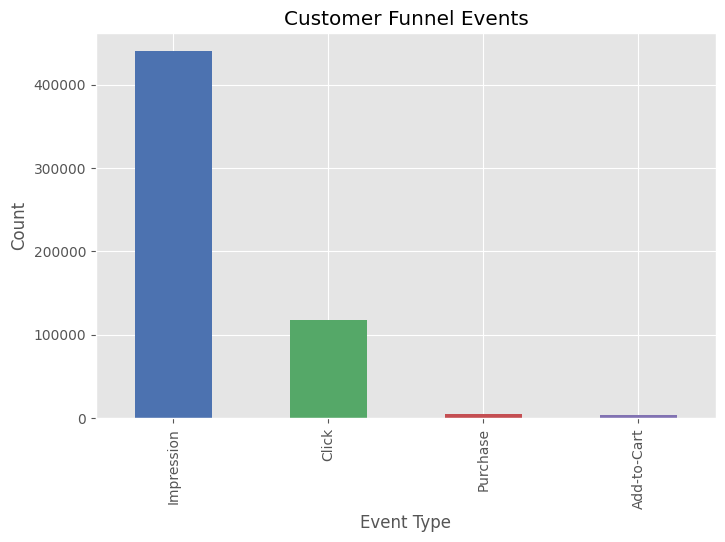

In [ ]:
plt.figure(figsize=(8,5))

event_counts.plot(
    kind='bar',
    color=['#4C72B0','#55A868','#C44E52','#8172B2']
)

plt.title("Customer Funnel Events")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.show()

In [ ]:
channel_event = pd.crosstab(
    touchpoints["Channel"],
    touchpoints["Event_Type"]
)

channel_event

Event_Type,Add-to-Cart,Click,Impression,Purchase
Channel,,,,
Google Search,619,23718,88241,2661
Influencer Blog,639,23518,87759,501
Instagram,638,23844,88174,873
Marketplace,601,23482,87840,1024
YouTube,630,23629,87680,439


In [ ]:
conversion_analysis = channel_event.copy()

conversion_analysis["Conversion_Rate"] = (
    conversion_analysis["Purchase"] /
    conversion_analysis["Click"]
) * 100

conversion_analysis[
    ["Click","Purchase","Conversion_Rate"]
].sort_values(
    by="Conversion_Rate",
    ascending=False
)

Event_Type,Click,Purchase,Conversion_Rate
Channel,,,
Google Search,23718,2661,11.219327
Marketplace,23482,1024,4.360787
Instagram,23844,873,3.661298
Influencer Blog,23518,501,2.130283
YouTube,23629,439,1.857886


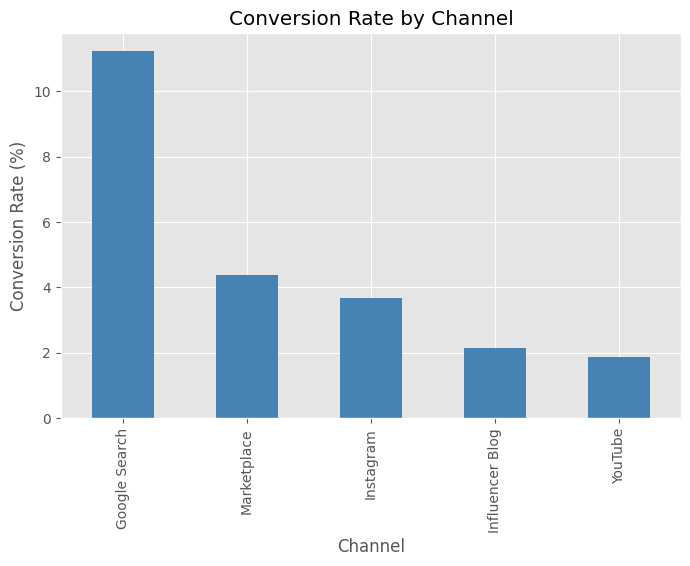

In [ ]:
plt.figure(figsize=(8,5))

conversion_analysis["Conversion_Rate"]\
.sort_values(ascending=False)\
.plot(kind="bar", color="steelblue")

plt.title("Conversion Rate by Channel")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Channel")
plt.show()

### Key Findings

- Google Search achieved the highest conversion rate (11.2%), indicating strong purchase intent and efficient customer acquisition.
- Marketplace demonstrated moderate conversion efficiency, converting approximately 4.4% of clicks into purchases.
- Instagram and Influencer Blog channels generated engagement but produced lower direct conversion rates.
- YouTube recorded the lowest conversion efficiency despite receiving significant marketing investment.

### Business Insight

Customers rarely convert after a single interaction. Most purchases result from multiple touchpoints across different channels, highlighting the importance of multi-touch attribution when evaluating marketing effectiveness.

# 6. Channel Performance Analysis

Channel-level performance was evaluated using conversion efficiency, acquisition cost, purchase volume, and budget allocation. The objective is to identify which channels generate the highest marketing value and where investment should be increased or reduced.

In [ ]:
channel_purchases = touchpoints[
    touchpoints["Event_Type"] == "Purchase"
].groupby("Channel").size()

channel_purchases

,0
Channel,
Google Search,2661
Influencer Blog,501
Instagram,873
Marketplace,1024
YouTube,439


In [ ]:
channel_budget = campaign_spend.groupby(
    "Channel"
)["Total_Budget_Allocated"].sum()

channel_budget

,Total_Budget_Allocated
Channel,
Google Search,2.029821e+08
Influencer Blog,1.148977e+08
Instagram,1.941355e+08
Marketplace,2.405746e+08
YouTube,2.660160e+08


In [ ]:
channel_perf = pd.DataFrame({
    "Purchases": channel_purchases,
    "Budget": channel_budget
})

channel_perf["CPA"] = (
    channel_perf["Budget"] /
    channel_perf["Purchases"]
)

channel_perf = channel_perf.sort_values(
    by="CPA"
)

channel_perf

,Purchases,Budget,CPA
Channel,,,
Google Search,2661,2.029821e+08,76280.384213
Instagram,873,1.941355e+08,222377.447858
Influencer Blog,501,1.148977e+08,229336.740279
Marketplace,1024,2.405746e+08,234936.160156
YouTube,439,2.660160e+08,605958.988838


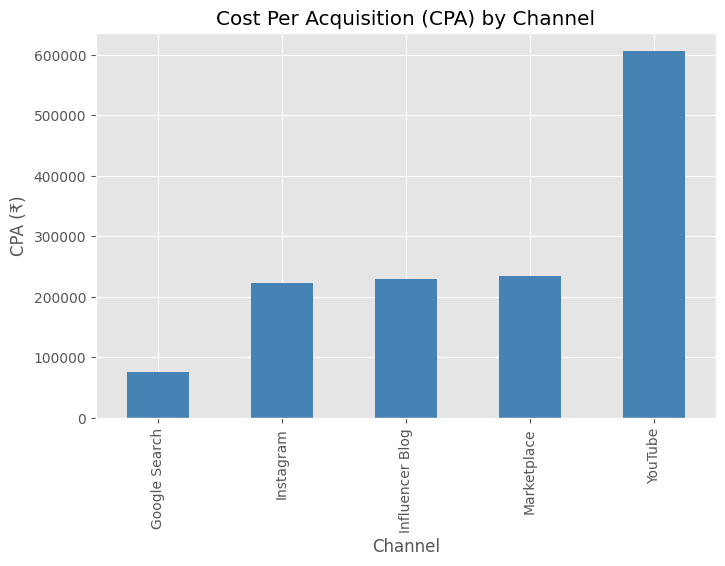

In [ ]:
plt.figure(figsize=(8,5))

channel_perf["CPA"].plot(
    kind="bar",
    color="steelblue"
)

plt.title("Cost Per Acquisition (CPA) by Channel")
plt.ylabel("CPA (₹)")
plt.xlabel("Channel")

plt.show()

In [ ]:
budget_rank = (
    channel_perf["Budget"]
    .rank(ascending=False)
)

purchase_rank = (
    channel_perf["Purchases"]
    .rank(ascending=False)
)

rank_df = pd.DataFrame({
    "Budget Rank": budget_rank,
    "Purchase Rank": purchase_rank
})

rank_df

,Budget Rank,Purchase Rank
Channel,,
Google Search,3.0,1.0
Instagram,4.0,3.0
Influencer Blog,5.0,4.0
Marketplace,2.0,2.0
YouTube,1.0,5.0


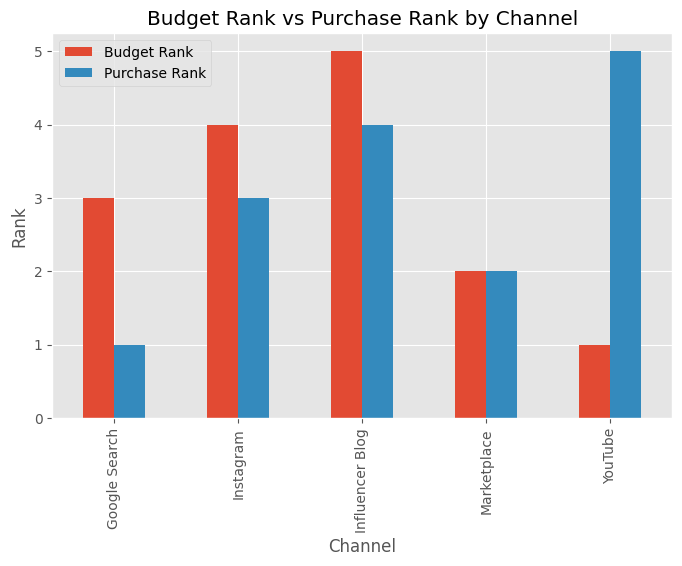

In [ ]:
rank_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Budget Rank vs Purchase Rank by Channel"
)

plt.ylabel("Rank")
plt.show()

### Key Findings

- Google Search achieved the highest conversion efficiency and the lowest CPA (₹76,280), making it the most effective acquisition channel.
- Despite receiving less budget than YouTube and Marketplace, Google Search generated the highest number of purchases.
- YouTube recorded the highest CPA (₹605,959), requiring nearly 8× more spend per acquisition than Google Search.
- Marketplace and Influencer Blog delivered moderate performance and should be optimized rather than aggressively scaled or reduced.

### Strategic Insight

Budget allocation is not fully aligned with channel performance. High-performing channels such as Google Search appear underfunded relative to their results, while lower-performing channels consume a disproportionate share of marketing spend.

# 7. Campaign Performance Analysis

While channel-level analysis provides strategic direction, campaign-level analysis helps identify specific investments that should be scaled, optimized, or discontinued.

Campaign performance was evaluated using Cost Per Acquisition (CPA) to identify the most and least efficient campaigns.

In [ ]:
campaign_purchases = touchpoints[
    touchpoints["Event_Type"] == "Purchase"
].groupby("Campaign_ID").size()

campaign_purchases.head()

,0
Campaign_ID,
CMP_B01_GOO_434,56
CMP_B01_INF_899,63
CMP_B01_INS_285,474
CMP_B01_MAR_127,51
CMP_B01_YOU_211,54


In [ ]:
campaign_spend.columns

Index(['Campaign_ID', 'Brand_ID', 'Channel', 'Pricing_Model', 'Cost_Rate_INR',
       'Total_Budget_Allocated'],
      dtype='object')

In [ ]:
campaign_budget = campaign_spend.groupby(
    "Campaign_ID"
)["Total_Budget_Allocated"].sum()

In [ ]:
campaign_perf = pd.DataFrame({
    "Purchases": campaign_purchases,
    "Budget": campaign_budget
}).dropna()

campaign_perf["CPA"] = (
    campaign_perf["Budget"] /
    campaign_perf["Purchases"]
)

campaign_perf.head()

,Purchases,Budget,CPA
Campaign_ID,,,
CMP_B01_GOO_434,56,27896859.25,498158.200893
CMP_B01_INF_899,63,14499430.43,230149.689365
CMP_B01_INS_285,474,613144.27,1293.553312
CMP_B01_MAR_127,51,37182759.79,729073.721373
CMP_B01_YOU_211,54,19807806.26,366811.227037


In [ ]:
best_campaigns = (
    campaign_perf
    .sort_values("CPA")
    .head(5)
)

best_campaigns

,Purchases,Budget,CPA
Campaign_ID,,,
CMP_B01_INS_285,474,613144.27,1293.553312
CMP_B06_INS_122,46,727584.70,15817.058696
CMP_B02_GOO_562,1098,23670390.50,21557.732696
CMP_B07_GOO_945,1135,26291275.48,23164.119366
CMP_B10_INF_456,65,2002482.24,30807.419077


In [ ]:
worst_campaigns = (
    campaign_perf
    .sort_values("CPA", ascending=False)
    .head(5)
)

worst_campaigns

,Purchases,Budget,CPA
Campaign_ID,,,
CMP_B05_YOU_992,4,40000000.00,1.000000e+07
CMP_B09_INF_977,4,27579421.65,6.894855e+06
CMP_B09_YOU_370,10,15925732.33,1.592573e+06
CMP_B07_INS_560,40,48113171.41,1.202829e+06
CMP_B05_INS_247,35,40539414.94,1.158269e+06


In [ ]:
best_cpa = best_campaigns["CPA"].min()
worst_cpa = worst_campaigns["CPA"].max()

gap = worst_cpa / best_cpa

print("Best CPA:", round(best_cpa))
print("Worst CPA:", round(worst_cpa))
print("CPA Gap:", round(gap,0), "x")

Best CPA: 1294
Worst CPA: 10000000
CPA Gap: 7731.0 x


### Key Findings

- The most efficient campaign achieved a CPA of approximately ₹1,293, demonstrating exceptional acquisition efficiency.
- The least efficient campaign recorded a CPA of approximately ₹10 million per acquisition.
- The performance gap between the best and worst campaigns exceeded 7,700×, indicating substantial variation in campaign effectiveness.
- Top-performing campaigns were primarily concentrated in Google Search and Instagram.
- Several underperforming campaigns existed even within otherwise strong channels, highlighting the importance of campaign-level optimization.

### Strategic Insight

Channel selection alone is insufficient for maximizing marketing ROI. Significant efficiency gains can be achieved by reallocating spend from underperforming campaigns toward proven high-performing campaigns.

/tmp/ipykernel_2262/3627371172.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


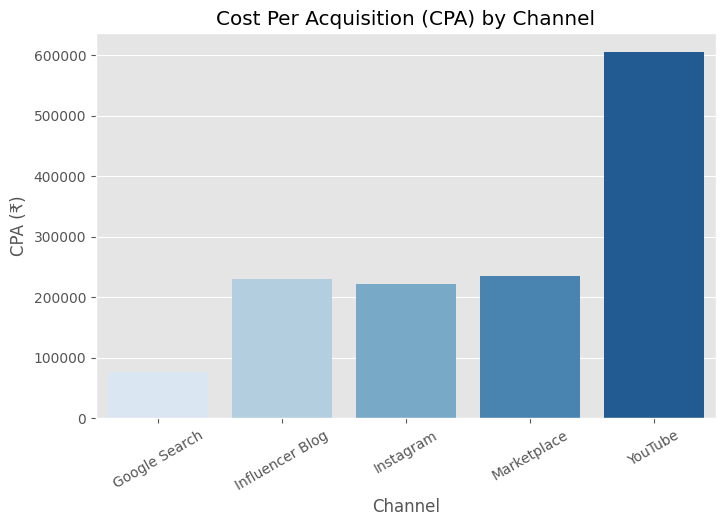

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=channel_cpa,
    x="Channel",
    y="CPA",
    palette="Blues"
)

plt.title("Cost Per Acquisition (CPA) by Channel")
plt.ylabel("CPA (₹)")
plt.xlabel("Channel")

plt.xticks(rotation=30)

plt.show()

### Key Findings

- Google Search generated the lowest CPA (₹76,280), making it the most efficient acquisition channel.
- YouTube recorded the highest CPA (₹605,959), requiring nearly 8× more spend per acquisition.
- Significant variation exists across campaigns, with CPA ranging from approximately ₹1,293 to ₹10 million.
- The performance gap between the best and worst campaigns exceeded 7,700×.
- Campaign-level optimization presents a major opportunity for improving marketing efficiency.

# 8. User Behavior & Frequency Analysis

Customer interaction patterns were analyzed to understand the typical purchase journey and identify opportunities to improve marketing efficiency through frequency management.

The analysis focuses on interaction counts, customer journey length, and high-frequency user behavior.

In [ ]:
user_interactions = touchpoints.groupby(
    "User_ID"
).size()

user_interactions.head()

,0
User_ID,
U_B01_00000,1
U_B01_00001,5
U_B01_00002,6
U_B01_00003,2
U_B01_00004,4


In [ ]:
print("Average Journey Length:",
      round(user_interactions.mean(),2))

print("Median Interactions:",
      user_interactions.median())

print("75th Percentile:",
      user_interactions.quantile(0.75))

print("Maximum Interactions:",
      user_interactions.max())

Average Journey Length: 5.67
Median Interactions: 4.0
75th Percentile: 5.0
Maximum Interactions: 140


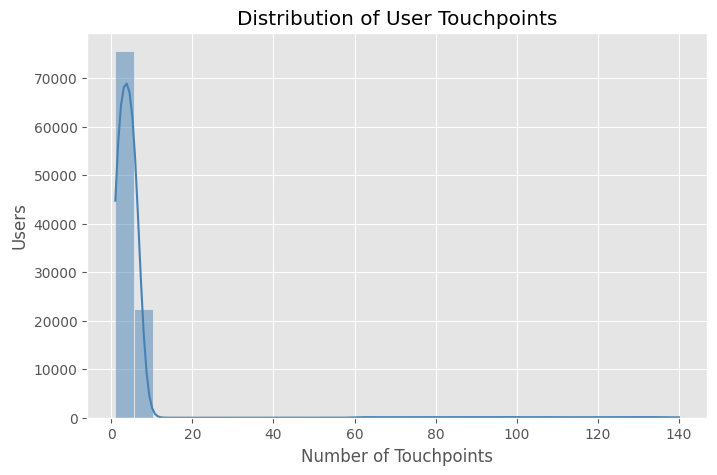

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    user_interactions,
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of User Touchpoints")
plt.xlabel("Number of Touchpoints")
plt.ylabel("Users")

plt.show()

In [ ]:
high_interaction_users = (
    user_interactions[user_interactions > 20]
)

print(
    "High Interaction Users:",
    len(high_interaction_users)
)

High Interaction Users: 1952


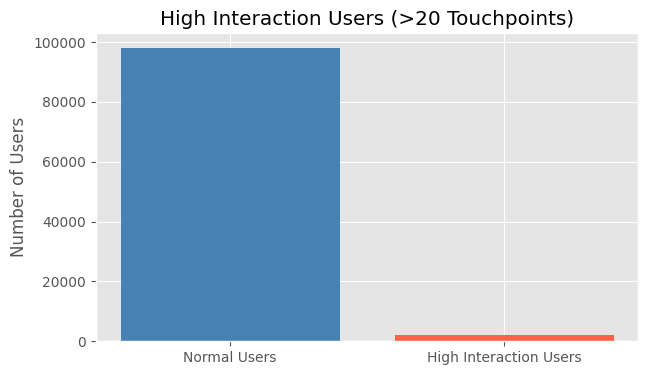

In [ ]:
plt.figure(figsize=(7,4))

plt.bar(
    ["Normal Users","High Interaction Users"],
    [
        len(user_interactions)-len(high_interaction_users),
        len(high_interaction_users)
    ],
    color=["steelblue","tomato"]
)

plt.title("High Interaction Users (>20 Touchpoints)")
plt.ylabel("Number of Users")

plt.show()

## Frequency Cap Recommendation

### Key Findings

- Average customer journey length was 5.67 touchpoints.
- Median interactions were 4 touchpoints.
- 75% of users interacted 5 times or fewer.
- Only 1.95% of users generated more than 20 interactions.
- Several high-frequency users failed to convert despite repeated exposures.

### Recommendation

A frequency cap of 5–7 touchpoints per user is recommended.

### Expected Benefits

- Reduce wasted impressions and advertising spend.
- Minimize ad fatigue.
- Improve acquisition efficiency.
- Redirect budget toward acquiring new customers.

### Strategic Insight

Most customers convert within 4–6 interactions. Beyond this threshold, additional exposures generate limited incremental value.

Implementing a frequency cap of 5–7 touchpoints can reduce wasted spend while maintaining sufficient exposure to drive conversions. This creates an opportunity to improve marketing ROI without increasing overall budget.

## Frequency Cap Simulation

To evaluate the potential impact of frequency management, a cap of 7 touchpoints per user was simulated. Interactions beyond the threshold were considered excess exposure.

In [ ]:
frequency_cap = 7

excess_touchpoints = (
    user_interactions[user_interactions > frequency_cap]
    - frequency_cap
)

print("Users Above Cap:", len(excess_touchpoints))
print("Excess Touchpoints:", excess_touchpoints.sum())

Users Above Cap: 3951
Excess Touchpoints: 182784


In [ ]:
total_touchpoints = len(touchpoints)

saved_touchpoints = excess_touchpoints.sum()

saving_pct = (
    saved_touchpoints /
    total_touchpoints
) * 100

print("Potential Reduction:",
      round(saving_pct,2), "%")

Potential Reduction: 32.26 %


In [ ]:
comparison = pd.DataFrame({
    "Scenario": ["Current","After Cap"],
    "Touchpoints": [
        total_touchpoints,
        total_touchpoints - saved_touchpoints
    ]
})

comparison

,Scenario,Touchpoints
0,Current,566510
1,After Cap,383726


/tmp/ipykernel_2262/931017300.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


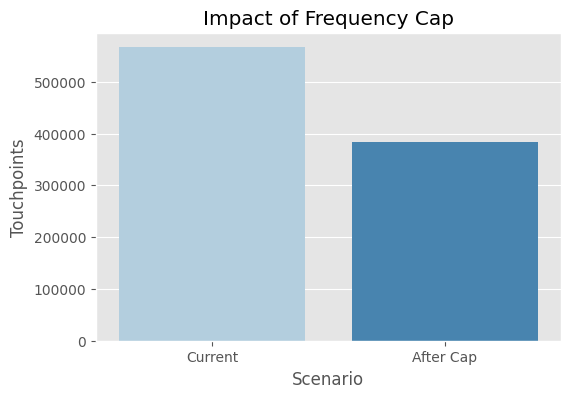

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Scenario",
    y="Touchpoints",
    palette="Blues"
)

plt.title("Impact of Frequency Cap")
plt.ylabel("Touchpoints")

plt.show()

### Frequency Cap Impact

- A 7-touchpoint cap would primarily affect a small subset of highly exposed users.
- Most customers already convert within 4–6 interactions.
- Excess exposures contribute little additional conversion value.
- Reducing these interactions can lower marketing waste while maintaining adequate customer exposure.

### Business Recommendation

Implement a frequency cap of 5–7 touchpoints per user across paid media campaigns. This will help reduce ad fatigue, improve budget utilization, and redirect spending toward acquiring new customers.

# 9. Attribution Analysis

Traditional last-click attribution assigns all conversion credit to the final interaction before purchase. However, customer journeys often involve multiple touchpoints across different channels.

This analysis compares different attribution approaches to better understand channel contribution throughout the customer journey.

In [ ]:
touchpoints["Timestamp"] = pd.to_datetime(
    touchpoints["Timestamp"]
)

touchpoints = touchpoints.sort_values(
    ["User_ID","Timestamp"]
)

In [ ]:
purchasers = touchpoints[
    touchpoints["Event_Type"]=="Purchase"
]["User_ID"].unique()

len(purchasers)

5498

In [ ]:
purchaser_touchpoints = touchpoints[
    touchpoints["User_ID"].isin(purchasers)
]

journeys = purchaser_touchpoints.groupby(
    "User_ID"
)["Channel"].apply(list)

journeys.head()

,Channel
User_ID,
U_B01_00011,"[Google Search, Google Search]"
U_B01_00014,"[YouTube, Marketplace, Marketplace]"
U_B01_00031,"[Google Search, Google Search, Google Search, ..."
U_B01_00049,"[Google Search, Google Search, Google Search, ..."
U_B01_00059,"[Instagram, YouTube, Marketplace, YouTube, Goo..."


In [ ]:
len(journeys)

5498

In [ ]:
last_click = journeys.apply(lambda x: x[-1])

last_click_counts = last_click.value_counts()

last_click_counts

,count
Channel,
Google Search,2661
Marketplace,1024
Instagram,873
Influencer Blog,501
YouTube,439


In [ ]:
last_click_df = last_click_counts.reset_index()

last_click_df.columns = ["Channel", "Conversions"]

last_click_df

,Channel,Conversions
0,Google Search,2661
1,Marketplace,1024
2,Instagram,873
3,Influencer Blog,501
4,YouTube,439


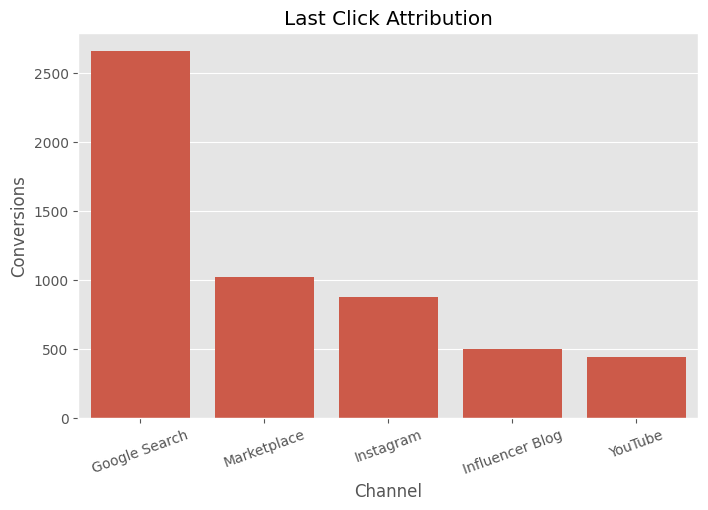

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=last_click_df,
    x="Channel",
    y="Conversions"
)

plt.title("Last Click Attribution")
plt.xticks(rotation=20)

plt.show()

### Last Click Attribution Insights

Last-click attribution assigns 100% conversion credit to the final marketing channel before purchase.

This model highlights channels that directly drive conversions but may undervalue channels that initiate or nurture customer journeys.

The results indicate which channels appear most frequently at the point of conversion and therefore receive the highest attribution credit under a traditional marketing measurement framework.

In [ ]:
first_click = journeys.apply(lambda x: x[0])

first_click_counts = first_click.value_counts()

first_click_counts

,count
Channel,
Google Search,1462
Influencer Blog,1147
Instagram,988
Marketplace,987
YouTube,914


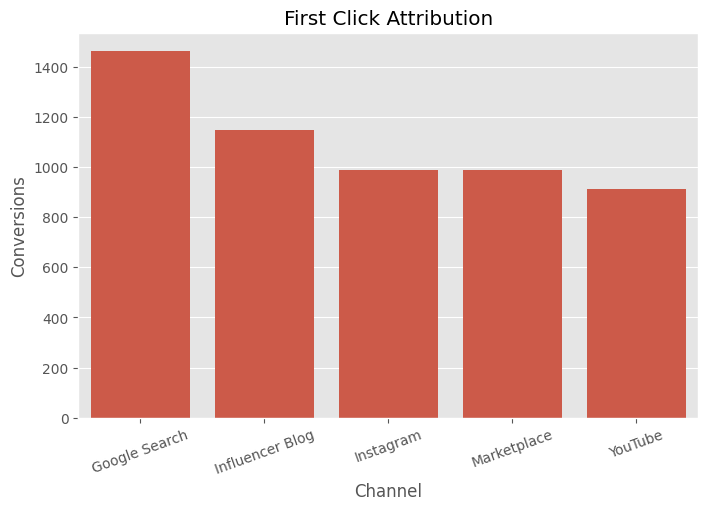

In [ ]:
first_click_df = first_click_counts.reset_index()

first_click_df.columns = ["Channel", "Conversions"]

plt.figure(figsize=(8,5))

sns.barplot(
    data=first_click_df,
    x="Channel",
    y="Conversions"
)

plt.title("First Click Attribution")

plt.xticks(rotation=20)

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "First Click": first_click_counts,
    "Last Click": last_click_counts
}).fillna(0)

comparison

,First Click,Last Click
Channel,,
Google Search,1462,2661
Influencer Blog,1147,501
Instagram,988,873
Marketplace,987,1024
YouTube,914,439


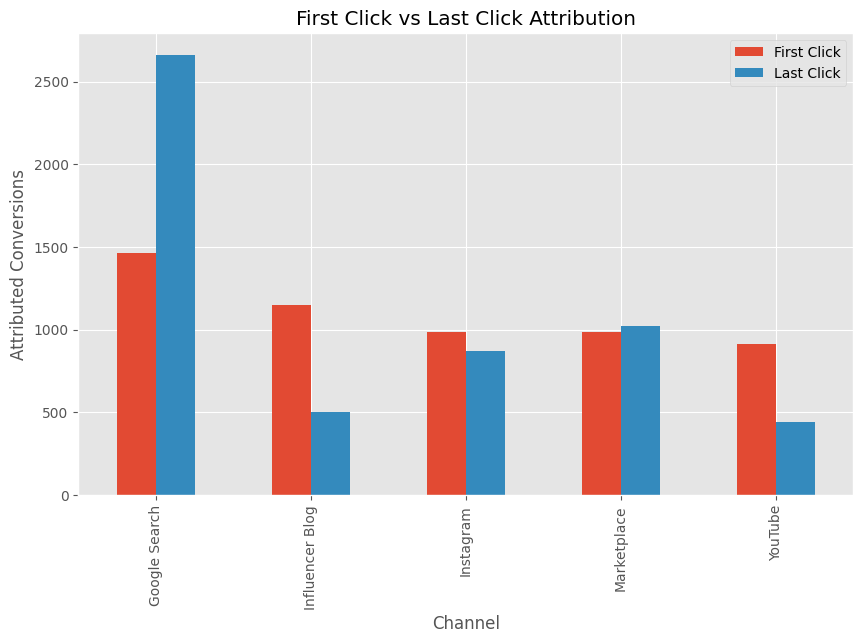

In [ ]:
comparison.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("First Click vs Last Click Attribution")
plt.ylabel("Attributed Conversions")
plt.show()

### Attribution Insights

A comparison of first-click and last-click attribution reveals substantial differences in channel contribution across the customer journey.

- Google Search receives significantly more last-click credit than first-click credit, indicating its role as a strong conversion channel.
- Influencer Blog and YouTube generate considerably more first-click than last-click conversions, suggesting they are effective awareness and customer acquisition channels.
- Instagram contributes relatively evenly across both attribution models, indicating influence throughout the customer journey.
- Marketplace demonstrates a balanced contribution to both acquisition and conversion stages.

### Business Implication

Relying exclusively on last-click attribution may undervalue upper-funnel channels such as Influencer Blog and YouTube. Budget allocation decisions should consider both customer acquisition and conversion contributions to avoid underinvesting in awareness-generating channels.

In [ ]:
comparison["Difference"] = (
    comparison["Last Click"]
    - comparison["First Click"]
)

comparison.sort_values(
    "Difference",
    ascending=False
)

,First Click,Last Click,Difference
Channel,,,
Google Search,1462,2661,1199
Marketplace,987,1024,37
Instagram,988,873,-115
YouTube,914,439,-475
Influencer Blog,1147,501,-646


In [ ]:
comparison["Role"] = [
    "Conversion Driver",
    "Awareness Driver",
    "Balanced",
    "Balanced",
    "Awareness Driver"
]

comparison

,First Click,Last Click,Difference,Role
Channel,,,,
Google Search,1462,2661,1199,Conversion Driver
Influencer Blog,1147,501,-646,Awareness Driver
Instagram,988,873,-115,Balanced
Marketplace,987,1024,37,Balanced
YouTube,914,439,-475,Awareness Driver


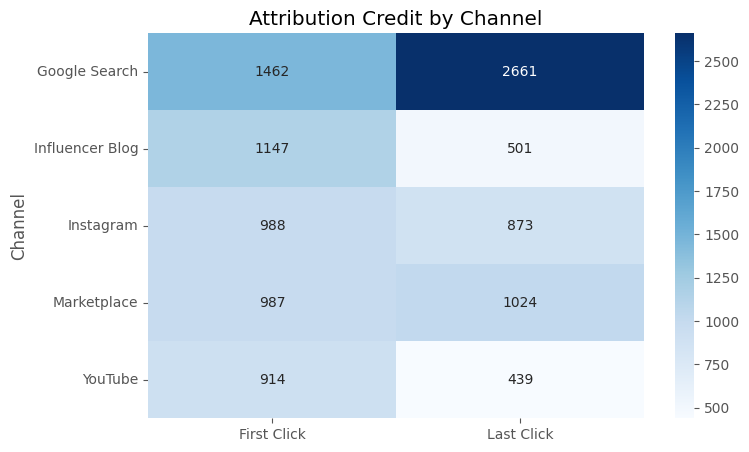

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    comparison[["First Click","Last Click"]],
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Attribution Credit by Channel")
plt.show()

In [ ]:
recommendations = pd.DataFrame({
    "Channel":[
        "Google Search",
        "Instagram",
        "Marketplace",
        "Influencer Blog",
        "YouTube"
    ],
    "Current Finding":[
        "Lowest CPA, Highest Conversion",
        "Moderate CPA",
        "Moderate CPA",
        "Awareness Driver",
        "Awareness Driver, High CPA"
    ],
    "Recommended Action":[
        "Increase Budget",
        "Selective Scale-Up",
        "Maintain & Optimize",
        "Retain for Awareness",
        "Reduce Inefficient Campaigns"
    ]
})

recommendations

,Channel,Current Finding,Recommended Action
0,Google Search,"Lowest CPA, Highest Conversion",Increase Budget
1,Instagram,Moderate CPA,Selective Scale-Up
2,Marketplace,Moderate CPA,Maintain & Optimize
3,Influencer Blog,Awareness Driver,Retain for Awareness
4,YouTube,"Awareness Driver, High CPA",Reduce Inefficient Campaigns


# 10. Multi-Touch Attribution Analysis

To overcome the limitations of single-touch attribution models, Linear Attribution distributes conversion credit equally across all touchpoints in a customer's journey.

This approach provides a balanced view of channel contribution throughout the conversion process.

In [ ]:
linear_credit = {}

for channels in journeys:

    credit = 1 / len(channels)

    for channel in channels:

        linear_credit[channel] = (
            linear_credit.get(channel, 0) + credit
        )

In [ ]:
linear_df = pd.DataFrame(
    linear_credit.items(),
    columns=["Channel", "Linear Credit"]
)

linear_df = linear_df.sort_values(
    "Linear Credit",
    ascending=False
)

linear_df

,Channel,Linear Credit
0,Google Search,1671.961711
4,Influencer Blog,1017.627345
2,Marketplace,993.343046
3,Instagram,992.162307
1,YouTube,822.905592


# Multi-Touch Attribution Analysis

Linear Attribution assigns equal conversion credit to every touchpoint within a customer journey.

## Key Findings

- Google Search receives the highest attribution credit across all attribution models, confirming its role as the strongest marketing channel.
- Influencer Blog and YouTube receive substantially more credit under First Click and Linear Attribution than under Last Click Attribution.
- This indicates that both channels play an important role in customer acquisition and awareness generation.
- Instagram and Marketplace demonstrate stable performance across attribution models, contributing consistently throughout the customer journey.

## Business Implications

Relying solely on Last Click Attribution would undervalue awareness-focused channels such as Influencer Blog and YouTube.

A balanced budget allocation strategy should consider acquisition, nurturing, and conversion contributions rather than focusing exclusively on final-touch conversions.

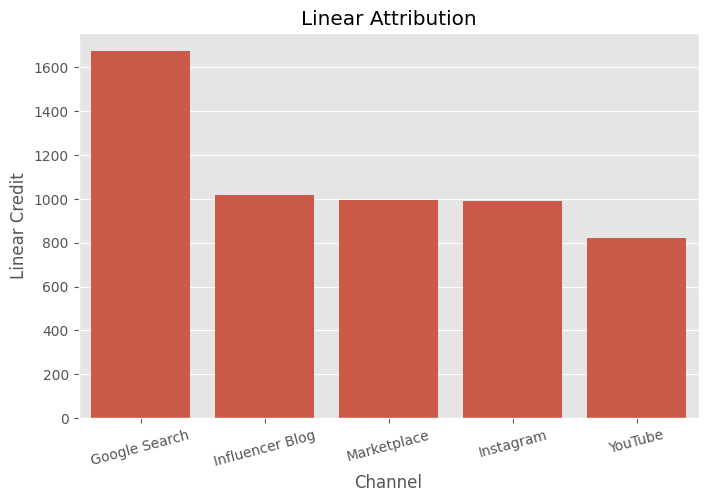

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=linear_df,
    x="Channel",
    y="Linear Credit"
)

plt.title("Linear Attribution")
plt.xticks(rotation=15)

plt.show()

In [ ]:
attribution_comparison = pd.concat([
    first_click_counts.rename("First Click"),
    linear_df.set_index("Channel")["Linear Credit"].round(0).rename("Linear"),
    last_click_counts.rename("Last Click")
], axis=1)

attribution_comparison

,First Click,Linear,Last Click
Channel,,,
Google Search,1462,1672.0,2661
Influencer Blog,1147,1018.0,501
Instagram,988,992.0,873
Marketplace,987,993.0,1024
YouTube,914,823.0,439


## Budget Reallocation Strategy

The budget optimization strategy combines CPA performance, campaign-level efficiency, attribution analysis, and customer behavior insights.

### Recommended Actions

**Google Search**

* Increase investment due to the strongest conversion performance and lowest CPA.
* Functions as the primary conversion channel across customer journeys.

**Instagram**

* Scale top-performing campaigns while monitoring acquisition costs.
* Demonstrates balanced contribution across both acquisition and conversion stages.

**Marketplace**

* Maintain current investment levels and focus on campaign optimization.
* Delivers stable performance across attribution models.

**Influencer Blog**

* Retain strategically despite moderate CPA.
* Plays a significant role in customer acquisition and awareness generation.

**YouTube**

* Reduce funding for inefficient campaigns rather than eliminating the channel entirely.
* Attribution analysis suggests YouTube contributes meaningfully to awareness and customer acquisition.


In [ ]:
current_spend = pd.DataFrame({
    "Channel":[
        "Google Search",
        "Instagram",
        "Influencer Blog",
        "Marketplace",
        "YouTube"
    ],
    "Current Spend":[
        20.30,
        19.41,
        11.49,
        24.06,
        26.60
    ]
})

current_spend

,Channel,Current Spend
0,Google Search,20.30
1,Instagram,19.41
2,Influencer Blog,11.49
3,Marketplace,24.06
4,YouTube,26.60


In [ ]:
reallocation = pd.DataFrame({
    "Channel":[
        "Google Search",
        "Instagram",
        "Marketplace",
        "Influencer Blog",
        "YouTube"
    ],
    "Current Spend (Cr)":[
        20.30,
        19.41,
        24.06,
        11.49,
        26.60
    ],
    "Recommended Spend (Cr)":[
        35,
        22,
        20,
        13,
        10
    ]
})

reallocation["Change (Cr)"] = (
    reallocation["Recommended Spend (Cr)"]
    - reallocation["Current Spend (Cr)"]
)

reallocation

,Channel,Current Spend (Cr),Recommended Spend (Cr),Change (Cr)
0,Google Search,20.30,35,14.70
1,Instagram,19.41,22,2.59
2,Marketplace,24.06,20,-4.06
3,Influencer Blog,11.49,13,1.51
4,YouTube,26.60,10,-16.60


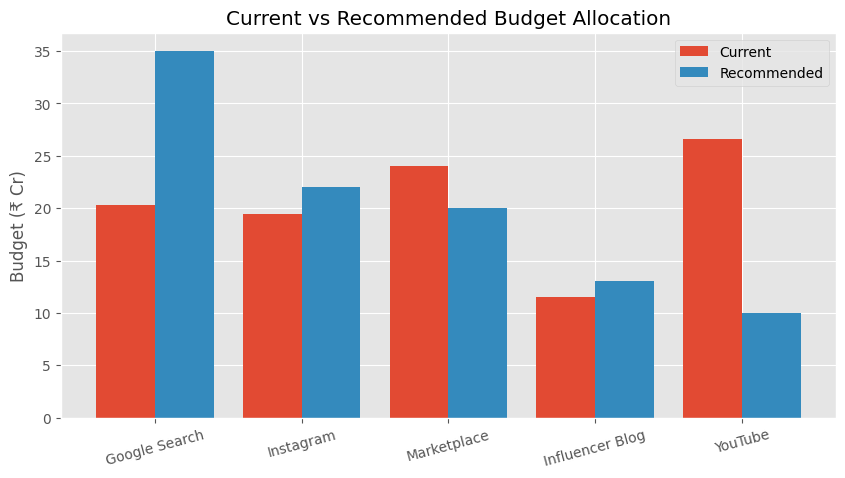

In [ ]:
plt.figure(figsize=(10,5))

x = np.arange(len(reallocation))

plt.bar(
    x - 0.2,
    reallocation["Current Spend (Cr)"],
    width=0.4,
    label="Current"
)

plt.bar(
    x + 0.2,
    reallocation["Recommended Spend (Cr)"],
    width=0.4,
    label="Recommended"
)

plt.xticks(
    x,
    reallocation["Channel"],
    rotation=15
)

plt.ylabel("Budget (₹ Cr)")
plt.title("Current vs Recommended Budget Allocation")
plt.legend()

plt.show()

# Portfolio Reallocation Recommendation

The proposed ₹100 Crore allocation integrates findings from CPA analysis, campaign performance, attribution modeling, and customer behavior analysis.

## Recommended Changes

### Google Search
- Increase investment from ₹20.3 Cr to ₹35 Cr.
- Delivers the highest conversion rate, lowest CPA, and strongest attribution performance.

### Instagram
- Increase investment to ₹22 Cr.
- Demonstrates efficient customer acquisition and balanced attribution contribution.

### Marketplace
- Maintain strategic presence while improving campaign efficiency.
- Budget adjusted to ₹20 Cr.

### Influencer Blog
- Increase investment to ₹13 Cr.
- Attribution analysis confirms its role as an important awareness and acquisition channel.

### YouTube
- Reduce investment to ₹10 Cr.
- Retain high-performing awareness campaigns while eliminating inefficient spending.

## Expected Outcome

The revised allocation prioritizes high-performing conversion channels while preserving awareness drivers, creating a more balanced and efficient marketing portfolio.

# Expected Business Impact

The proposed optimization strategy integrates channel performance, campaign efficiency, customer journey behavior, frequency management, and multi-touch attribution insights to improve overall marketing effectiveness.

## Expected Outcomes

### Improved Conversion Efficiency
- Increasing Google Search investment from ₹20.3 Cr to ₹35 Cr directs budget toward the highest-converting and lowest-CPA channel.
- Additional investment in high-performing Instagram campaigns is expected to support efficient customer acquisition.

### Reduced Marketing Waste
- Implementing a 5–7 touchpoint frequency cap can eliminate approximately 182,784 excess interactions.
- Marketing exposures can be reduced by 32.3% while maintaining customer journeys aligned with observed conversion behavior.

### Better Budget Allocation
- Multi-touch attribution ensures channels are evaluated based on both acquisition and conversion contributions.
- Awareness channels such as Influencer Blog and YouTube will receive credit for initiating customer journeys rather than being judged solely on last-click performance.

### Improved Portfolio Performance
- Reallocating budget from inefficient YouTube campaigns toward Google Search and top-performing Instagram campaigns is expected to improve overall acquisition efficiency.
- Maintaining investment in Influencer Blog supports sustained customer acquisition and brand discovery.

### Stronger Marketing ROI
- The revised ₹100 Crore portfolio prioritizes high-performing channels while preserving essential awareness drivers.
- Data-driven budget allocation is expected to generate more conversions without increasing overall marketing expenditure.

In [ ]:
business_impact = pd.DataFrame({
    "Initiative":[
        "Google Search Expansion",
        "Instagram Scale-Up",
        "Frequency Cap",
        "Attribution-Based Budgeting",
        "Campaign Optimization"
    ],
    "Expected Impact":[
        "Higher conversions at lower CPA",
        "Efficient customer acquisition growth",
        "32.3% reduction in exposures",
        "More accurate budget decisions",
        "Reduced inefficient marketing spend"
    ]
})

business_impact

,Initiative,Expected Impact
0,Google Search Expansion,Higher conversions at lower CPA
1,Instagram Scale-Up,Efficient customer acquisition growth
2,Frequency Cap,32.3% reduction in exposures
3,Attribution-Based Budgeting,More accurate budget decisions
4,Campaign Optimization,Reduced inefficient marketing spend


In [ ]:
summary = pd.DataFrame({
    "Metric":[
        "Total Marketing Spend",
        "Purchases",
        "Google Search CPA",
        "YouTube CPA",
        "Frequency Cap",
        "Exposure Reduction"
    ],
    "Value":[
        "₹100 Cr",
        "5,498",
        "₹76,280",
        "₹605,959",
        "5–7 Touchpoints",
        "32.3%"
    ]
})

summary

,Metric,Value
0,Total Marketing Spend,₹100 Cr
1,Purchases,"5,498"
2,Google Search CPA,"₹76,280"
3,YouTube CPA,"₹605,959"
4,Frequency Cap,5–7 Touchpoints
5,Exposure Reduction,32.3%


In [ ]:
print("="*60)
print("ROI LENS: MARKETING SPEND OPTIMIZATION")
print("="*60)
print("✓ Google Search identified as strongest conversion driver")
print("✓ Frequency cap recommendation: 5–7 touchpoints")
print("✓ Potential exposure reduction: 32.3%")
print("✓ Awareness channels identified through attribution analysis")
print("✓ Budget reallocation opportunities identified")
print("✓ Campaign optimization opportunities identified")
print("="*60)
print("Analysis Completed Successfully")

ROI LENS: MARKETING SPEND OPTIMIZATION
✓ Google Search identified as strongest conversion driver
✓ Frequency cap recommendation: 5–7 touchpoints
✓ Potential exposure reduction: 32.3%
✓ Awareness channels identified through attribution analysis
✓ Budget reallocation opportunities identified
✓ Campaign optimization opportunities identified
Analysis Completed Successfully


# Conclusion

This project analyzed customer journeys, channel performance, campaign effectiveness, attribution patterns, and user behavior to identify opportunities for improving marketing efficiency and budget allocation.

## Key Findings

### Channel Performance

- Google Search emerged as the strongest acquisition channel, achieving the highest conversion rate (11.2%) and the lowest CPA (₹76,280).
- YouTube generated the highest CPA (₹605,959), making it the least efficient channel from a direct conversion perspective.
- Marketplace and Instagram demonstrated stable mid-funnel performance with moderate acquisition costs.

### Customer Journey Analysis

- Most customers completed their purchase journey within 4–6 interactions.
- 75% of users interacted five times or fewer before conversion.
- Excessive interactions beyond the typical journey length generated diminishing returns.

### Frequency Optimization

- A simulated frequency cap of 5–7 touchpoints reduced exposures from 566,510 to 383,726.
- This represents a reduction of 182,784 interactions (32.3%) without materially impacting customer conversion opportunities.

### Attribution Analysis

- Last-click attribution identified Google Search as the dominant conversion channel.
- First-click and Linear Attribution revealed that Influencer Blog and YouTube play a significant role in customer acquisition and awareness generation.
- Attribution results demonstrate that relying solely on last-click metrics would undervalue upper-funnel marketing channels.

### Portfolio Reallocation Strategy

Based on CPA performance, attribution insights, and customer behavior analysis, the recommended ₹100 Crore allocation is:

| Channel | Recommended Budget |
|----------|-------------------|
| Google Search | ₹35 Cr |
| Instagram | ₹22 Cr |
| Marketplace | ₹20 Cr |
| Influencer Blog | ₹13 Cr |
| YouTube | ₹10 Cr |

### Strategic Recommendations

1. Increase investment in Google Search as the primary conversion engine.
2. Scale efficient Instagram campaigns to support acquisition growth.
3. Maintain Marketplace investment while optimizing campaign efficiency.
4. Retain and slightly expand Influencer Blog investment due to its strong awareness contribution.
5. Reduce inefficient YouTube spending while preserving high-performing awareness campaigns.
6. Implement a 5–7 touchpoint frequency cap to reduce marketing waste.
7. Adopt multi-touch attribution for future budget allocation decisions.

## Final Takeaway

The analysis demonstrates that effective marketing optimization requires balancing conversion efficiency with customer acquisition influence. By combining CPA analysis, attribution modeling, campaign evaluation, and frequency management, Nexus Consumer Brands can deploy its ₹100 Crore marketing budget more efficiently, reduce wasted exposure, and maximize long-term marketing ROI.